# Annotations

📄 Source: https://matplotlib.org/stable/users/explain/text/annotations.html

Annotations are graphical elements, usually text, that explain, add context to, or highlight part of the data. `ax.annotate` supports many coordinate systems for placing the text and the point, plus an optional arrow from the text to the data. (`ax.text` also works for simple notes, but is less flexible.)

This is the tool for "a chart that makes an argument": one arrow pointing at the evidence.

**Skipped (as planned):** custom box styles, customizing annotation arrows in depth, anchored artists, ConnectionPatch, zoom effect.

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

print("matplotlib", mpl.__version__)

matplotlib 3.11.2


## Basic annotation

Two points matter: **`xy`** = the location being annotated (arrow tip), and **`xytext`** = where the text goes. Both are `(x, y)` tuples.

(-2.0, 2.0)

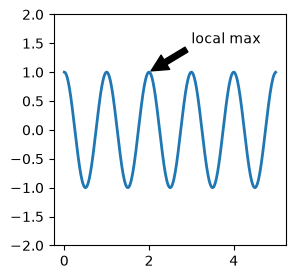

In [2]:
fig, ax = plt.subplots(figsize=(3, 3))

t = np.arange(0.0, 5.0, 0.01)
s = np.cos(2*np.pi*t)
line, = ax.plot(t, s, lw=2)

ax.annotate('local max', xy=(2, 1), xytext=(3, 1.5),           # both in data coordinates
            arrowprops=dict(facecolor='black', shrink=0.05))   # draw an arrow from text to xy
ax.set_ylim(-2, 2)

Both points above are in **data** coordinates (the default). Choose another system with `xycoords` (for `xy`) and `textcoords` (for `xytext`):

| argument | coordinate system |
| :-- | :-- |
| `'figure points'` | points from the lower left corner of the figure |
| `'figure pixels'` | pixels from the lower left corner of the figure |
| `'figure fraction'` | (0, 0) is lower left of figure and (1, 1) is upper right |
| `'axes points'` | points from lower left corner of the Axes |
| `'axes pixels'` | pixels from lower left corner of the Axes |
| `'axes fraction'` | (0, 0) is lower left of Axes and (1, 1) is upper right |
| `'data'` | use the axes data coordinate system |

Extra options for `textcoords` only:

| argument | coordinate system |
| :-- | :-- |
| `'offset points'` | offset (in points) from the xy value |
| `'offset pixels'` | offset (in pixels) from the xy value |

Points are typographic points: 1 pt = 1/72 inch.

### Annotating data

Here the **text** is placed in axes fraction coordinates (top-left corner of the Axes), while the arrow still points at a data point:

(-2.0, 2.0)

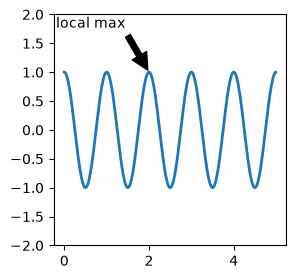

In [3]:
fig, ax = plt.subplots(figsize=(3, 3))

t = np.arange(0.0, 5.0, 0.01)
s = np.cos(2*np.pi*t)
line, = ax.plot(t, s, lw=2)

ax.annotate('local max', xy=(2, 1), xycoords='data',          # arrow tip: data point (2, 1)
            xytext=(0.01, .99), textcoords='axes fraction',   # text: top-left of the Axes
            va='top', ha='left',
            arrowprops=dict(facecolor='black', shrink=0.05))
ax.set_ylim(-2, 2)

### Annotating an Artist

Pass an Artist as `xycoords`; then `xy` is a fraction of that Artist's bounding box.

[(1.0, 2.0), (1.0, 2.0)]

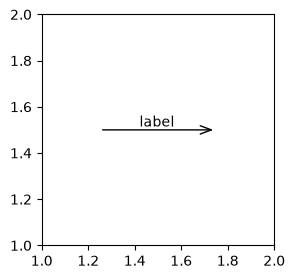

In [4]:
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(3, 3))
arr = mpatches.FancyArrowPatch((1.25, 1.5), (1.75, 1.5),
                               arrowstyle='->,head_width=.15', mutation_scale=20)
ax.add_patch(arr)
ax.annotate("label", (.5, .5), xycoords=arr, ha='center', va='bottom')   # middle of the arrow's bbox
ax.set(xlim=(1, 2), ylim=(1, 2))

The label sits at (0.5, 0.5) of the arrow's bounding box; `va='bottom'` puts its bottom edge there, so it appears just above the line.

### Annotating with arrows

Give `arrowprops` a dict to draw an arrow from the text to the point:

| `arrowprops` key | description |
| :-- | :-- |
| width | the width of the arrow in points |
| frac | the fraction of the arrow length occupied by the head |
| headwidth | the width of the base of the arrow head in points |
| shrink | move the tip and base some percent away from the annotated point and text |
| \*\*kwargs | any key for `matplotlib.patches.Polygon`, e.g. `facecolor` |

Below, `xy` is in data coordinates (on a **polar** Axes that means (theta, radius)), and the text is in figure fraction coordinates. Text keyword arguments (`horizontalalignment`, `fontsize`...) are passed on to the `Text`.

Text(0.05, 0.05, 'a polar annotation')

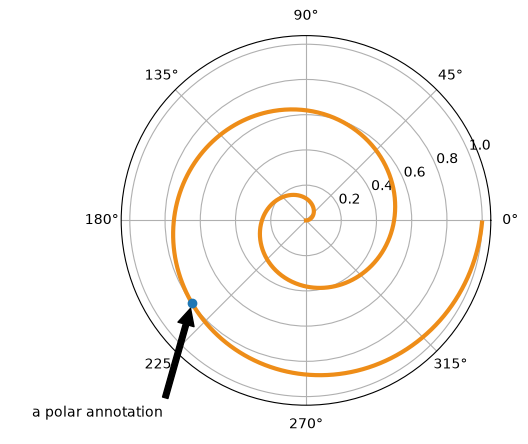

In [5]:
fig = plt.figure()
ax = fig.add_subplot(projection='polar')
r = np.arange(0, 1, 0.001)
theta = 2 * 2*np.pi * r
line, = ax.plot(theta, r, color='#ee8d18', lw=3)

ind = 800
thisr, thistheta = r[ind], theta[ind]
ax.plot([thistheta], [thisr], 'o')          # mark the point we annotate
ax.annotate('a polar annotation',
            xy=(thistheta, thisr),  # theta, radius
            xytext=(0.05, 0.05),    # fraction, fraction
            textcoords='figure fraction',
            arrowprops=dict(facecolor='black', shrink=0.05),
            horizontalalignment='left',
            verticalalignment='bottom')

### Placing text annotations relative to data

`textcoords='offset points'` (or `'offset pixels'`) places the text at a fixed **offset** from `xy`. This is the standard way to label points without the text sitting on top of the marker.

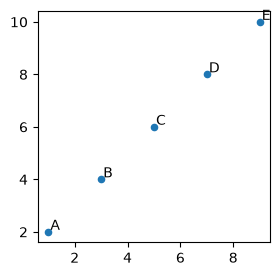

In [6]:
fig, ax = plt.subplots(figsize=(3, 3))
x = [1, 3, 5, 7, 9]
y = [2, 4, 6, 8, 10]
annotations = ["A", "B", "C", "D", "E"]
ax.scatter(x, y, s=20)

for xi, yi, text in zip(x, y, annotations):
    ax.annotate(text,
                xy=(xi, yi), xycoords='data',
                xytext=(1.5, 1.5), textcoords='offset points')   # 1.5 pt right and up from each point

The labels are offset 1.5 points (1.5/72 inch) from the points.

## Advanced annotation

### Annotating with boxed text

`ax.text` takes a `bbox` keyword that draws a box around the text:

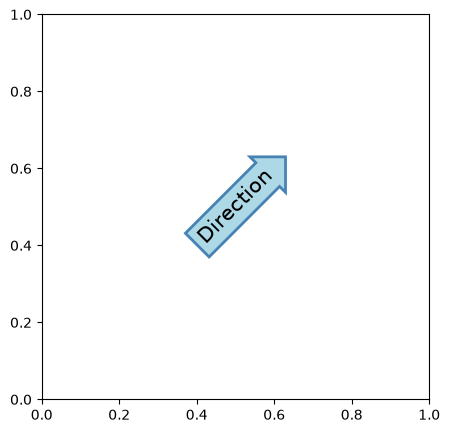

In [7]:
fig, ax = plt.subplots(figsize=(5, 5))
t = ax.text(0.5, 0.5, "Direction",
            ha="center", va="center", rotation=45, size=15,
            bbox=dict(boxstyle="rarrow,pad=0.3",           # box shape + its attributes
                      fc="lightblue", ec="steelblue", lw=2))

Available box styles:

| Class | Name | Attrs |
| :-- | :-- | :-- |
| Circle | `circle` | pad=0.3 |
| DArrow | `darrow` | pad=0.3,head_width=1.5,head_angle=90 |
| Ellipse | `ellipse` | pad=0.3 |
| LArrow | `larrow` | pad=0.3,head_width=1.5,head_angle=90 |
| RArrow | `rarrow` | pad=0.3,head_width=1.5,head_angle=90 |
| Round | `round` | pad=0.3,rounding_size=None |
| Round4 | `round4` | pad=0.3,rounding_size=None |
| Roundtooth | `roundtooth` | pad=0.3,tooth_size=None |
| Sawtooth | `sawtooth` | pad=0.3,tooth_size=None |
| Square | `square` | pad=0.3 |

The box is a `FancyBboxPatch`, reachable with `t.get_bbox_patch()`, so you can change it like any Artist:

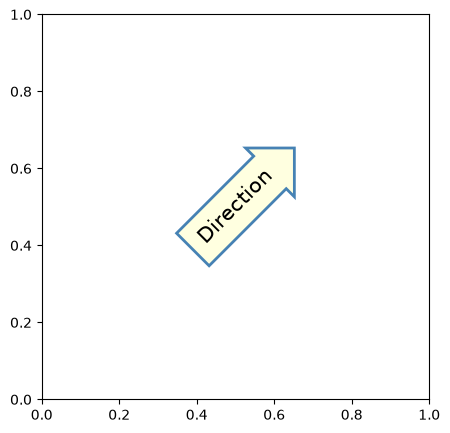

In [8]:
bb = t.get_bbox_patch()            # the box around the text
bb.set_boxstyle("rarrow", pad=0.6) # change shape attributes...
bb.set_facecolor("lightyellow")    # ...and normal patch properties
# The attributes can also go inside the style string: bb.set_boxstyle("rarrow, pad=0.6")
fig

A quick look at every box style (my addition, so the table above has pictures):

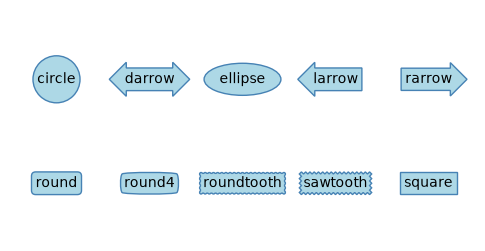

In [9]:
styles = ["circle", "darrow", "ellipse", "larrow", "rarrow",
          "round", "round4", "roundtooth", "sawtooth", "square"]
fig, ax = plt.subplots(figsize=(6, 3))
for i, style in enumerate(styles):
    ax.text(0.1 + (i % 5) * 0.2, 0.7 - (i // 5) * 0.45, style, ha="center", va="center",
            size=10, bbox=dict(boxstyle=style, fc="lightblue", ec="steelblue"))
ax.set_axis_off()

## Coordinate systems for annotations (skim)

Besides the strings in the table, `xycoords`/`textcoords` also accept:

### Transform instance
`ax.transAxes` is identical to `'axes fraction'`:

Text(0.2, 0.2, 'Test')

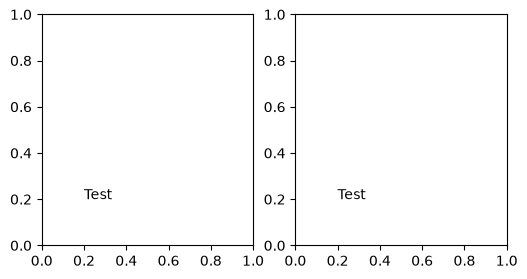

In [10]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(6, 3))
ax1.annotate("Test", xy=(0.2, 0.2), xycoords=ax1.transAxes)      # transform object
ax2.annotate("Test", xy=(0.2, 0.2), xycoords="axes fraction")    # same thing as a string

`ax.transData` of **another** Axes lets you connect points across two Axes (empty text, just the arrow):

Text(0, 0, '')

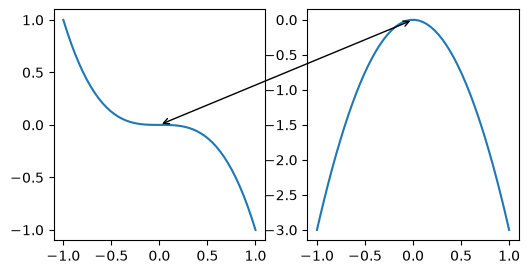

In [11]:
x = np.linspace(-1, 1)

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(6, 3))
ax1.plot(x, -x**3)
ax2.plot(x, -3*x**2)
ax2.annotate("",
             xy=(0, 0), xycoords=ax1.transData,       # point (0, 0) in the LEFT Axes
             xytext=(0, 0), textcoords=ax2.transData, # point (0, 0) in the RIGHT Axes
             arrowprops=dict(arrowstyle="<->"))

### Artist instance
`xy` is a fraction of another artist's bounding box. Useful to chain annotations (the first must be drawn before the second):

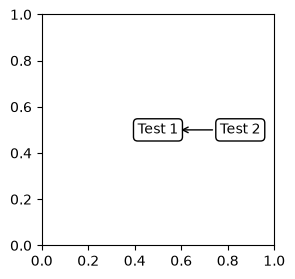

In [12]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(3, 3))
an1 = ax.annotate("Test 1",
                  xy=(0.5, 0.5), xycoords="data",
                  va="center", ha="center",
                  bbox=dict(boxstyle="round", fc="w"))

an2 = ax.annotate("Test 2",
                  xy=(1, 0.5), xycoords=an1,  # (1, 0.5) of an1's bbox = middle of its right edge
                  xytext=(30, 0), textcoords="offset points",
                  va="center", ha="left",
                  bbox=dict(boxstyle="round", fc="w"),
                  arrowprops=dict(arrowstyle="->"))

### Blended coordinate specification
A tuple: the first system for x, the second for y. Here x=0.5 is **data**, y=1 is the **top of the Axes**. Handy for labelling a vertical event line on a time series:

[(0.0, 2.0), (1.0, 2.0)]

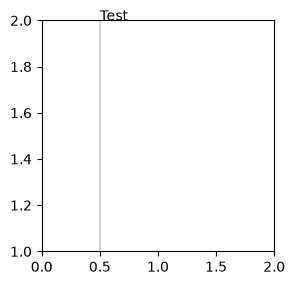

In [13]:
fig, ax = plt.subplots(figsize=(3, 3))
ax.annotate("Test", xy=(0.5, 1), xycoords=("data", "axes fraction"))
ax.axvline(x=.5, color='lightgray')
ax.set(xlim=(0, 2), ylim=(1, 2))

## Putting it together: an argument chart (my addition)

The title states the conclusion, one annotation points at the evidence, everything else is grey.

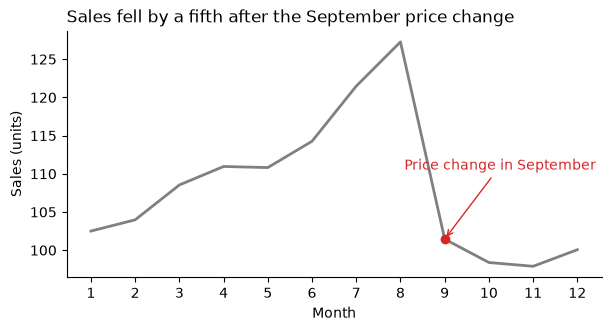

In [14]:
rng = np.random.default_rng(0)
months = np.arange(1, 13)
sales = 100 + np.cumsum(rng.normal(2, 4, 12))
sales[8:] -= 25                                   # a drop starting in month 9

fig, ax = plt.subplots(figsize=(6, 3.2), layout="constrained")
ax.plot(months, sales, color="grey", lw=2)
ax.plot(months[8], sales[8], "o", color="tab:red")  # highlight only the evidence point

ax.annotate("Price change in September",
            xy=(months[8], sales[8]), xycoords="data",
            xytext=(40, 50), textcoords="offset points",   # text 40 pt right and 50 pt above the point
            ha="center",
            arrowprops=dict(arrowstyle="->", color="tab:red"),
            color="tab:red")

ax.set_title("Sales fell by a fifth after the September price change", loc="left")
ax.set(xlabel="Month", ylabel="Sales (units)", xticks=months)
ax.spines[["top", "right"]].set_visible(False)

## Key takeaways

- `ax.annotate(text, xy=point, xytext=text_position, arrowprops=dict(...))`.
- `xycoords` / `textcoords` choose the coordinate system: `'data'` (default), `'axes fraction'`, `'figure fraction'`, `'offset points'`...
- Labelling points: `xytext=(dx, dy), textcoords='offset points'`.
- Fixed position on the Axes (e.g. a corner note): `'axes fraction'`.
- Boxes: `bbox=dict(boxstyle="round", fc="w")`. Blended coords: `xycoords=("data", "axes fraction")`.